In [1]:
# =============================================================================
# TMO / tmopy Tutorial – Human Brain
# =============================================================================
import os
import tmopy as tmo
import scanpy as sc
import matplotlib.pyplot as plt
import random
random.seed(8)

C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------------------------------------------------------------------------
# 1. Setup paths
# ---------------------------------------------------------------------------
h5_file = "./data/10x_human_brain/human_brain_3k_filtered_feature_bc_matrix.h5"
atac_annotation_file = "./data/10x_human_brain/human_brain_3k_atac_peak_annotation.tsv"
output_dir = "./results/tmo_results_human_brain_tmopy"
os.makedirs(output_dir, exist_ok=True)

In [3]:
# ---------------------------------------------------------------------------
# 2. Load and preprocess
# ---------------------------------------------------------------------------
adata = tmo.pp.read_10x_multiome(h5_file, atac_annotation_file)
print(adata)

C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Added `interval` annotation for features from data\10x_human_brain\human_brain_3k_filtered_feature_bc_matrix.h5


C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\mudata\_core\mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\mudata\_core\mudata.py:565: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\mudata\_core\mudata.py:1272: FutureWarning: F

AnnData object with n_obs × n_vars = 3185 × 36601
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval'
    uns: 'atac_annotation_file', 'peak_names'
    obsm: 'ATAC'


C:\Users\phabe\OneDrive\Escritorio\PhD_MUDS\TemporalMultiOmics\tmopy\pp\read.py:56: ImplicitModificationWarning: Setting element `.obsm['ATAC']` of view, initializing view as actual.
  adata_rna.obsm['ATAC'] = adata_atac.X
C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
# Compute Gene‑level ATAC (peaks -> genes)
adata = tmo.pp.compute_gene_level_atac(adata)
print("Gene-level ATAC matrix shape:", adata.obsm['ATAC_gene'].shape)

Building binary peak‑gene matrix...
M shape: (86394, 30496), non‑zeros: 85785
Peaks matched to genes: 85785/86394 (99.3%)
Computing gene‑activity matrix...
Gene‑activity shape: (3185, 30496), non‑zeros: 24028892
Gene-level ATAC matrix shape: (3185, 30496)


In [5]:
# Compute pseudotime, using Pax6 as early marker to orient the trajectory
adata = tmo.pp.compute_pseudotime(adata, root_marker="ASCL1")
print(f"Pseudotime range: {adata.obs['pseudotime'].min():.3f} – {adata.obs['pseudotime'].max():.3f}")
print(f"Dataset reversed: {adata.uns.get('pseudotime_reversed', False)}")

Reversed pseudotime so that ASCL1 increases with pseudotime.
Pseudotime range: 0.000 – 1.000
Pseudotime range: 0.000 – 1.000
Dataset reversed: True


C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [8]:
# ---------------------------------------------------------------------------
# 3. Annotate RNA components with GO terms (internet required)
# ---------------------------------------------------------------------------
component_annotation = tmo.tl.annotate_components(
    adata, n_components=50, n_top_genes=100, n_top_go=5, delay=2.0, organism='human'
)
component_annotation.head()

Running GO enrichment via Enrichr (delay 2.0s between requests)...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [03:25<00:00,  4.12s/it]


,Component,Top_genes,GO_terms
0,Comp0,"CTNNA3, ST18, NRG3, NRXN1, MBP, FAM155A, RNF22...",Regulation Of Potassium Ion Transport (GO:0043...
1,Comp1,"NRXN3, CNTNAP2, SLC1A2, CSMD1, RBFOX1, GPC5, S...",Chemical Synaptic Transmission (GO:0007268); A...
2,Comp2,"LSAMP, PCDH9, CADM2, NRXN1, ADGRL3, NPAS3, LRP...",Synapse Organization (GO:0050808); Synapse Ass...
3,Comp3,"LHFPL3, PCDH15, DSCAM, LUZP2, TNR, VCAN, SGCZ,...",Nervous System Development (GO:0007399); Neuro...
4,Comp4,"HSPH1, SPP1, PLXDC2, CD83, MEF2C, EPB41L2, LRM...",Regulation Of Small GTPase Mediated Signal Tra...


In [9]:
# ---------------------------------------------------------------------------
# 4. Train asymmetric model
#    (automatically saves best checkpoint + pca.pkl, tfidf.pkl, lsi.pkl)
# ---------------------------------------------------------------------------
model = tmo.tl.train_asymmetric(
    adata,
    epochs=50,
    val_interval=5,
    lambda_lag=0.1,
    batch_size=32,
    lr=1e-3,
    device='cpu',          # change to 'cuda' if GPU available
    save_model=os.path.join(output_dir, "tmo_asymmetric_best.pt"),
    output_dir=output_dir
)

Epoch  1 | recon 11.1885  lag 0.0017  LCS 0.8152
  -> Best model saved (LCS=0.8152)
Epoch  5 | recon 0.2247  lag 0.0003  LCS 0.9507
  -> Best model saved (LCS=0.9507)
Epoch 10 | recon 0.0761  lag 0.0003  LCS 0.8864
Epoch 15 | recon 0.0475  lag 0.0003  LCS 0.9414
Epoch 20 | recon 0.0411  lag 0.0002  LCS 0.9409
Epoch 25 | recon 0.0296  lag 0.0001  LCS 0.9712
  -> Best model saved (LCS=0.9712)
Epoch 30 | recon 0.0270  lag 0.0001  LCS 0.9535
Epoch 35 | recon 0.0245  lag 0.0001  LCS 0.9366
Epoch 40 | recon 0.0239  lag 0.0001  LCS 0.9806
  -> Best model saved (LCS=0.9806)
Epoch 45 | recon 0.0189  lag 0.0001  LCS 0.9839
  -> Best model saved (LCS=0.9839)
Epoch 50 | recon 0.0189  lag 0.0001  LCS 0.9884
  -> Best model saved (LCS=0.9884)
Training finished. Best LCS: 0.9884


In [8]:
# ---------------------------------------------------------------------------
# (Optional) Train symmetric baseline for comparison
# ---------------------------------------------------------------------------
sym_model = tmo.tl.train_symmetric(
    adata,
    epochs=50,
    val_interval=5,
    batch_size=32,
    lr=1e-3,
    device='cpu',
    save_model=os.path.join(output_dir, "tmo_symmetric_best.pt"),
    output_dir=output_dir
)

Epoch  1 | recon 5.0745  LCS -0.0092
  -> Best model saved (LCS=-0.0092)
Epoch  5 | recon 0.2187  LCS -0.0620
Epoch 10 | recon 0.0542  LCS -0.0537
Epoch 15 | recon 0.0330  LCS -0.0371
Epoch 20 | recon 0.0294  LCS -0.0268
Epoch 25 | recon 0.0168  LCS -0.0296
Epoch 30 | recon 0.0167  LCS -0.0305
Epoch 35 | recon 0.0168  LCS -0.0143
Epoch 40 | recon 0.0158  LCS -0.0104
Epoch 45 | recon 0.0110  LCS -0.0041
  -> Best model saved (LCS=-0.0041)
Epoch 50 | recon 0.0113  LCS -0.0066
Training finished. Best LCS: -0.0041


In [6]:
# ---------------------------------------------------------------------------
# 5. Evaluate asymmetric model -> Δτ heatmap (Figure 1)
# ---------------------------------------------------------------------------
delta_tau, pt_grid, lcs, row_labels = tmo.tl.evaluate_asymmetric(
    adata,
    model_path=os.path.join(output_dir, "tmo_asymmetric_best.pt"),
    n_components=50,
    cluster_aggregate=True,
    dist_threshold=1.0,
    standardize=True
)
print(f"Lag Concordance Score (LCS): {lcs:.4f}")

Flipped Δτ signs for heatmap (positive = ATAC leads).
LCS (raw, for validation) = -0.0852
Retained 49 / 50 components for clustering (1 removed due to constant / NaN profiles).
Standardized Δτ profiles for clustering.
Number of clusters at threshold 1.0: 13
Lag Concordance Score (LCS): -0.0852


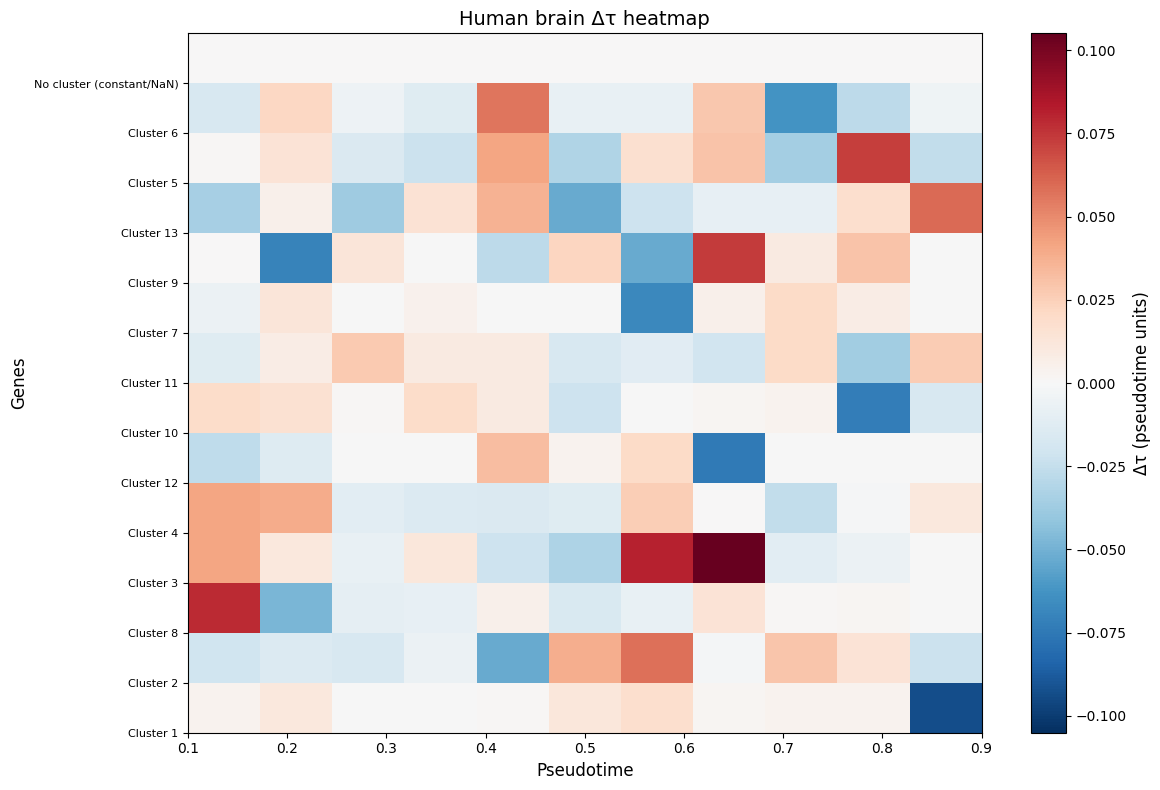

In [7]:
# Plot heatmap
fig1 = tmo.pl.plot_delta_tau(
    delta_tau,
    pt_grid,
    row_labels,
    title="Human brain Δτ heatmap",
    save=os.path.join(output_dir, "fig1_delta_tau.pdf"),
    show=False
)
plt.show()
plt.close(fig1)

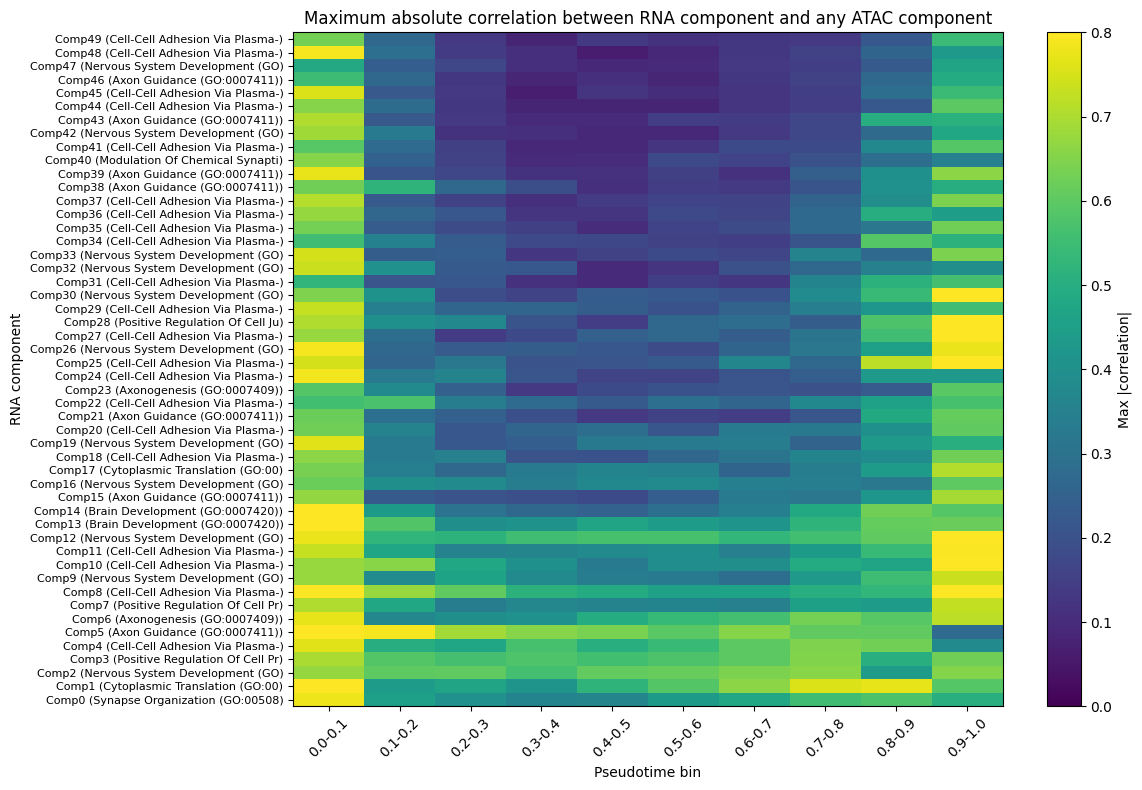

In [12]:
# ---------------------------------------------------------------------------
# 6. ATAC‑RNA correlation heatmap (Figure 2)
# ---------------------------------------------------------------------------
fig2 = tmo.pl.plot_correlation(
    adata,
    n_bins=10,
    save=os.path.join(output_dir, "fig2_correlation.pdf"),
    show=False
)
plt.show()
plt.close(fig2)


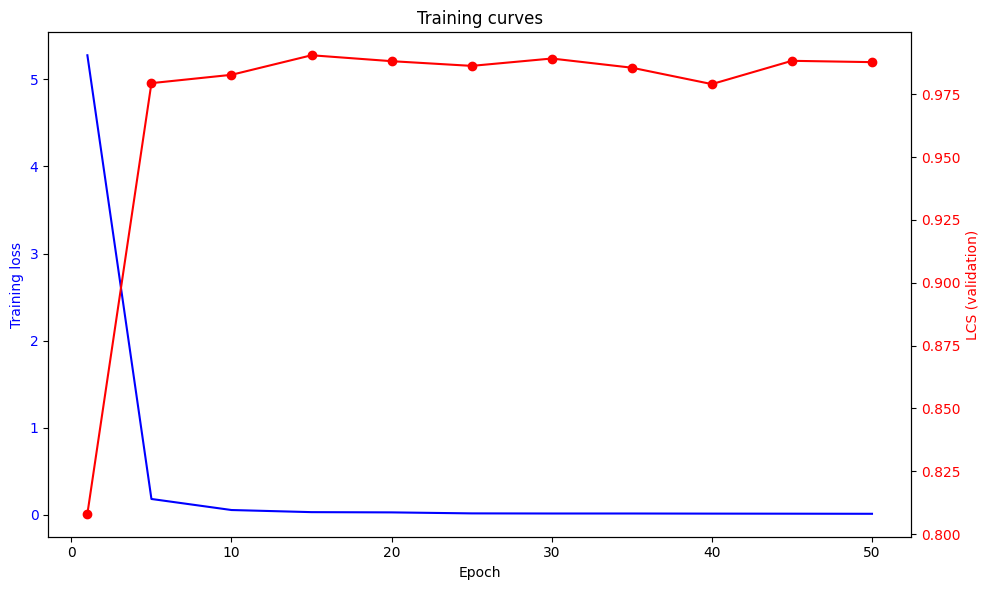

In [13]:
# ---------------------------------------------------------------------------
# 7. Plot training curves (Figure 3)
#    The training script saved a CSV file in the output directory.
# ---------------------------------------------------------------------------
metrics_csv = os.path.join(output_dir, "training_metrics_tmo_asymmetric.csv")
if os.path.exists(metrics_csv):
    fig3 = tmo.pl.plot_training_curves(
        metrics_csv,
        save=os.path.join(output_dir, "fig3_training_curves.pdf"),
        show=False
    )
    plt.show()
    plt.close(fig3)
else:
    print("Training metrics CSV not found; please adjust path.")


In [19]:
# ---------------------------------------------------------------------------
# 8. ChIP‑seq validation for ASCL1 (two‑sided)
# ---------------------------------------------------------------------------
target_file = "./data/10x_human_brain/ASCL1_top500_genes.txt"
if os.path.exists(target_file):
    print("Running ChIP‑seq validation for ASCL1...")
    # Pre‑fitted transformers are saved automatically by train_asymmetric,
    # but for a quick run you can omit them; the function will still work.
    chip_res = tmo.tl.validate_chipseq(
        adata,
        model_path=os.path.join(output_dir, "tmo_asymmetric_best.pt"),
        target_genes_file=target_file,
        match_expression=True,
        n_components=50,
        alternative='two-sided',
        pca=os.path.join(output_dir,"pca.pkl"),   # optional, for exact reproducibility
        tfidf=os.path.join(output_dir,"tfidf.pkl"),
        lsi=os.path.join(output_dir,"lsi.pkl")
    )
    print(f"ChIP‑seq validation p‑value: {chip_res['p_value']:.4e}")
    print(f"Target Δτ mean: {chip_res['mean_target']:.6f}, background Δτ mean: {chip_res['mean_background']:.6f}")
else:
    print(f"Target gene file {target_file} not found. Skipping ChIP‑seq validation.")

Running ChIP‑seq validation for Pax6...
Target genes found: 484
Expression‑matched background genes: 484

=== CCF‑based Δτ validation ===
Target Δτ mean: 0.006533, background Δτ mean: 0.005270
Mann‑Whitney U: 132872.0, p = 2.8877e-04
ChIP‑seq validation p‑value: 2.8877e-04
Target Δτ mean: 0.006533, background Δτ mean: 0.005270


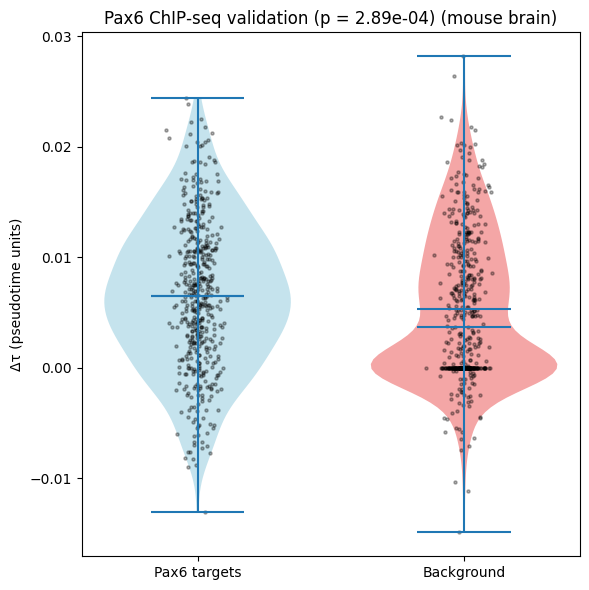

ChIP‑seq validation figure saved to fig4_chipseq_pax6.pdf


In [20]:
# ---------------------------------------------------------------------------
# 9. Violin plot for ChIP‑seq
# ---------------------------------------------------------------------------
if 'chip_res' in locals() and chip_res['p_value']:
    p_val = chip_res['p_value']
    fig4 = tmo.pl.plot_violin_validation(
        chip_res['target_lags'], chip_res['background_lags'],
        target_label="ASCL1 targets",
        background_label="Background",
        title=f"ASCL1 ChIP‑seq validation (p = {p_val:.2e}) (human brain)",
        ylabel="Δτ (pseudotime units)",
        save=os.path.join(output_dir, "fig4_chipseq_ASCL1.pdf"),
        show=False
    )
    plt.show()
    plt.close(fig4)
    print("ChIP‑seq validation figure saved to fig4_chipseq_ASCL1.pdf")
else:
    print("Run ChIP-seq validation first, to compute p-values.")

In [8]:
# ---------------------------------------------------------------------------
# 8. ChIP‑seq validation for NEUROD1 (two‑sided)
# ---------------------------------------------------------------------------
target_file = "./data/10x_human_brain/NEUROD1_top500_genes.txt"
if os.path.exists(target_file):
    print("Running ChIP‑seq validation for NEUROD1...")
    # Pre‑fitted transformers are saved automatically by train_asymmetric,
    # but for a quick run you can omit them; the function will still work.
    chip_res = tmo.tl.validate_chipseq(
        adata,
        model_path=os.path.join(output_dir, "tmo_asymmetric_best.pt"),
        target_genes_file=target_file,
        match_expression=True,
        n_components=50,
        alternative='two-sided',
        pca=os.path.join(output_dir,"pca.pkl"),   # optional, for exact reproducibility
        tfidf=os.path.join(output_dir,"tfidf.pkl"),
        lsi=os.path.join(output_dir,"lsi.pkl")
    )
    print(f"ChIP‑seq validation p‑value: {chip_res['p_value']:.4e}")
    print(f"Target Δτ mean: {chip_res['mean_target']:.6f}, background Δτ mean: {chip_res['mean_background']:.6f}")
else:
    print(f"Target gene file {target_file} not found. Skipping ChIP‑seq validation.")

Running ChIP‑seq validation for NEUROD1...
Target genes found: 458
Expression‑matched background genes: 458

=== CCF‑based Δτ validation ===
Target Δτ mean: -0.006274, background Δτ mean: -0.005636
Mann‑Whitney U: 95049.0, p = 1.4029e-02
ChIP‑seq validation p‑value: 1.4029e-02
Target Δτ mean: -0.006274, background Δτ mean: -0.005636


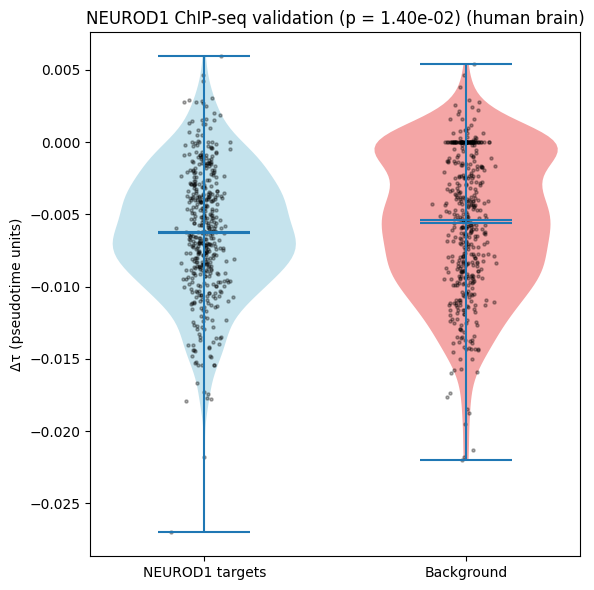

ChIP‑seq validation figure saved to fig4_chipseq_NEUROD1.pdf


In [10]:
# ---------------------------------------------------------------------------
# 9. Violin plot for ChIP‑seq
# ---------------------------------------------------------------------------
if 'chip_res' in locals() and chip_res['p_value']:
    p_val = chip_res['p_value']
    fig4 = tmo.pl.plot_violin_validation(
        chip_res['target_lags'], chip_res['background_lags'],
        target_label="NEUROD1 targets",
        background_label="Background",
        title=f"NEUROD1 ChIP‑seq validation (p = {p_val:.2e}) (human brain)",
        ylabel="Δτ (pseudotime units)",
        save=os.path.join(output_dir, "fig4_chipseq_NEUROD1.pdf"),
        show=False
    )
    plt.show()
    plt.close(fig4)
    print("ChIP‑seq validation figure saved to fig4_chipseq_NEUROD1.pdf")
else:
    print("Run ChIP-seq validation first, to compute p-values.")

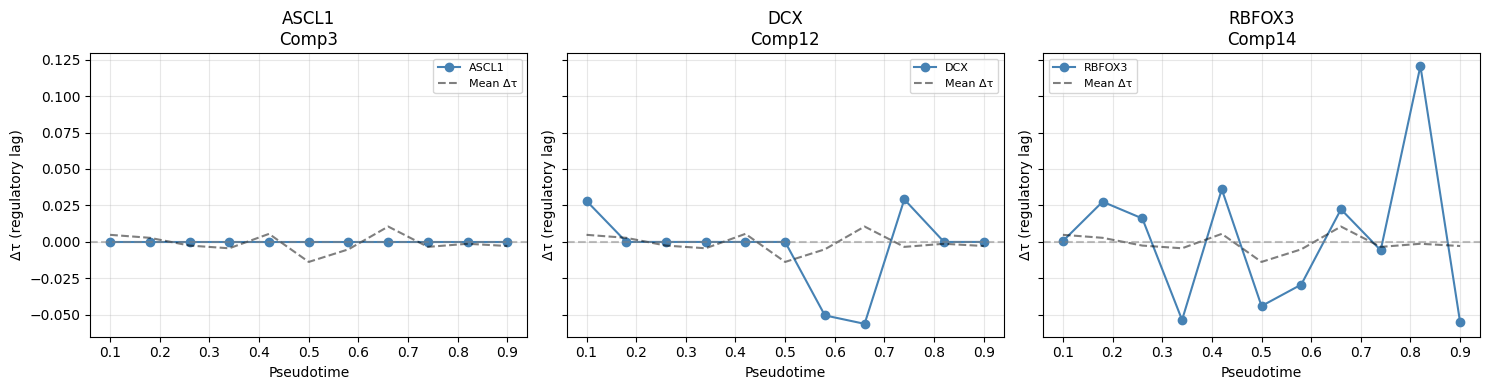

In [11]:
# ---------------------------------------------------------------------------
# (Optional) Marker gene Δτ profiles
# ---------------------------------------------------------------------------
fig_markers = tmo.pl.plot_marker_profiles(
    adata,
    marker_genes=["ASCL1", "DCX", "RBFOX3"],
    save=os.path.join(output_dir, "marker_profiles.pdf"),
    show=False
)
plt.show()
plt.close(fig_markers)

In [21]:
# ---------------------------------------------------------------------------
# 10. Summary
# ---------------------------------------------------------------------------
print("\nAnalysis completed. Results saved in:", output_dir)
print("Figure 1: Δτ heatmap (fig1_delta_tau.pdf)")
print("Figure 2: ATAC‑RNA correlation (fig2_correlation.pdf)")
print("Figure 3: Training curves (fig3_training_curves.pdf)")


Analysis completed. Results saved in: ./results/tmo_results_mouse_brain_tmopy
Figure 1: Δτ heatmap (fig1_delta_tau.pdf)
Figure 2: ATAC‑RNA correlation (fig2_correlation.pdf)
Figure 3: Training curves (fig3_training_curves.pdf)
